In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.storagelevel import StorageLevel
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

ĐOC DỮ LIỆU TỪ HDFS

In [2]:
spark = (
    SparkSession.builder
    #.master("spark://100.77.205.48:7077")
    .appName("NYC Taxi Data Query")
    #.config("spark.executor.memory", "1g")
    #.config("spark.driver.memory", "1g")
    .getOrCreate()
)

#print(spark.sparkContext.master)

In [3]:
spark.sparkContext.setLogLevel("WARN")

df = spark.read.parquet(
     #"hdfs://master:9000/output/yellow_taxi_cleaned"
     "hdfs://localhost:9000/output/yellow_taxi_cleaned"
 )

df.createOrReplaceTempView("yellow_taxi")

# Cache trong RAM
df.cache()

# Kích hoạt cache
print(f"Total records: {df.count():,}")


Total records: 3,502,694


QUERY 1: Khung giờ mang lại doanh thu cao nhất trong ngày

In [4]:
query1_df = spark.sql("""
WITH hourly_revenue AS
(
    SELECT
        pickup_hour,
        COUNT(*) AS Tong_so_chuyen,
        ROUND(SUM(total_amount),2) AS Doanh_thu
    FROM yellow_taxi
    GROUP BY pickup_hour
)

SELECT
    pickup_hour,
    Tong_so_chuyen,
    Doanh_thu,
    ROUND(
        Doanh_thu /SUM(Doanh_thu) OVER() * 100,2) AS Phan_tram_doanh_thu,
    RANK() OVER(
        ORDER BY Doanh_thu DESC
    ) AS Xep_hang_doanh_thu
FROM hourly_revenue
ORDER BY Doanh_thu DESC

""")
query1_df.show(24, truncate=False)

+-----------+--------------+----------+-------------------+------------------+
|pickup_hour|Tong_so_chuyen|Doanh_thu |Phan_tram_doanh_thu|Xep_hang_doanh_thu|
+-----------+--------------+----------+-------------------+------------------+
|18         |228732        |6704170.88|6.44               |1                 |
|17         |220132        |6649951.22|6.39               |2                 |
|15         |212528        |6384710.96|6.14               |3                 |
|16         |202614        |6351214.43|6.11               |4                 |
|19         |208256        |6183267.96|5.94               |5                 |
|21         |205522        |6132355.8 |5.9                |6                 |
|20         |205773        |6119502.43|5.88               |7                 |
|14         |198896        |5927777.04|5.7                |8                 |
|22         |188560        |5674594.28|5.46               |9                 |
|13         |187592        |5356383.94|5.15         

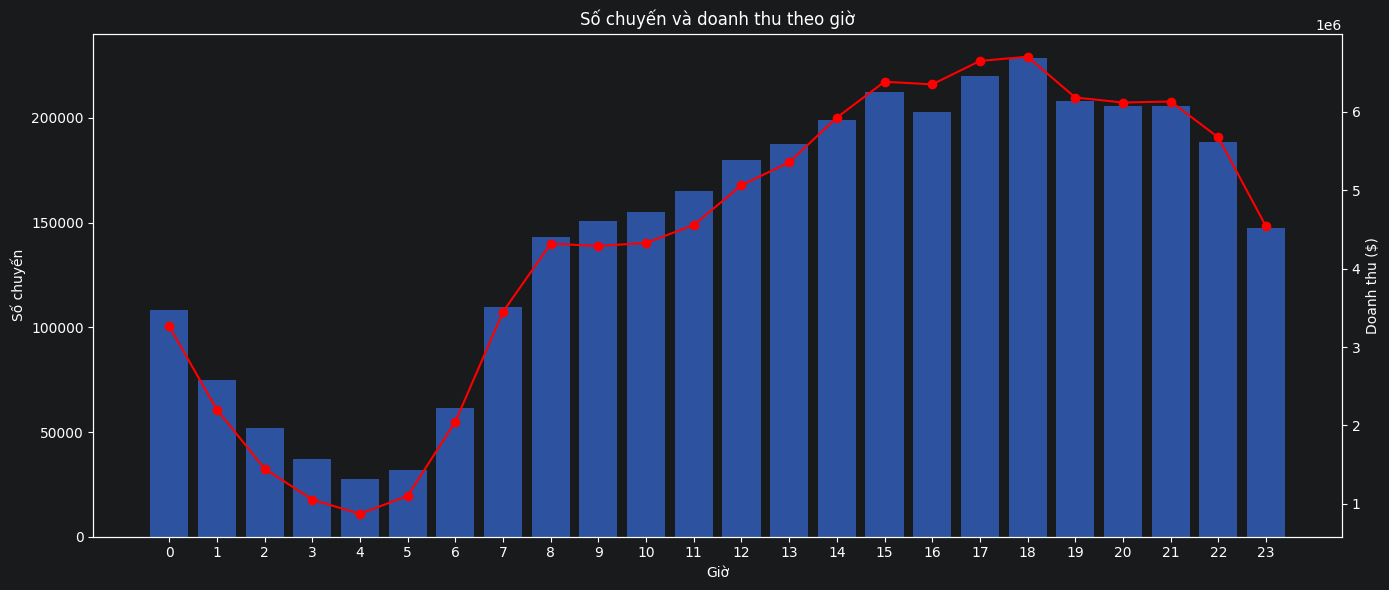

In [6]:
pdf = query1_df.toPandas()
pdf = pdf.sort_values("pickup_hour")
fig, ax1 = plt.subplots(figsize=(14,6))

ax1.bar(
    pdf["pickup_hour"],
    pdf["Tong_so_chuyen"],
    alpha=0.7)

ax1.set_ylabel("Số chuyến")
ax1.set_xlabel("Giờ")
ax2 = ax1.twinx()

ax2.plot(
    pdf["pickup_hour"],
    pdf["Doanh_thu"],
    marker="o",
    color ="red")

ax2.set_ylabel("Doanh thu ($)")
plt.title(
    "Số chuyến và doanh thu theo giờ")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

QUERY 2: Giờ cao điểm nào có hiệu quả nhất?

In [7]:
query2_df = spark.sql("""
SELECT
    pickup_hour,
    COUNT(*) AS Tong_so_chuyen,
    ROUND(
        SUM(total_amount),2) AS Doanh_thu,
    ROUND(
        SUM(total_amount)/COUNT(*),2) AS Doanh_thu_tren_chuyen
FROM yellow_taxi
GROUP BY pickup_hour
ORDER BY Doanh_thu_tren_chuyen DESC
""")

query2_df.show(24, truncate=False)

+-----------+--------------+----------+---------------------+
|pickup_hour|Tong_so_chuyen|Doanh_thu |Doanh_thu_tren_chuyen|
+-----------+--------------+----------+---------------------+
|5          |31701         |1101999.87|34.76                |
|6          |61576         |2047829.69|33.26                |
|4          |27494         |872286.62 |31.73                |
|7          |109606        |3450294.44|31.48                |
|16         |202614        |6351214.43|31.35                |
|23         |147622        |4538712.64|30.75                |
|17         |220132        |6649951.22|30.21                |
|8          |142943        |4318786.86|30.21                |
|0          |108107        |3263279.56|30.19                |
|22         |188560        |5674594.28|30.09                |
|15         |212528        |6384710.96|30.04                |
|21         |205522        |6132355.8 |29.84                |
|14         |198896        |5927777.04|29.8                 |
|20     

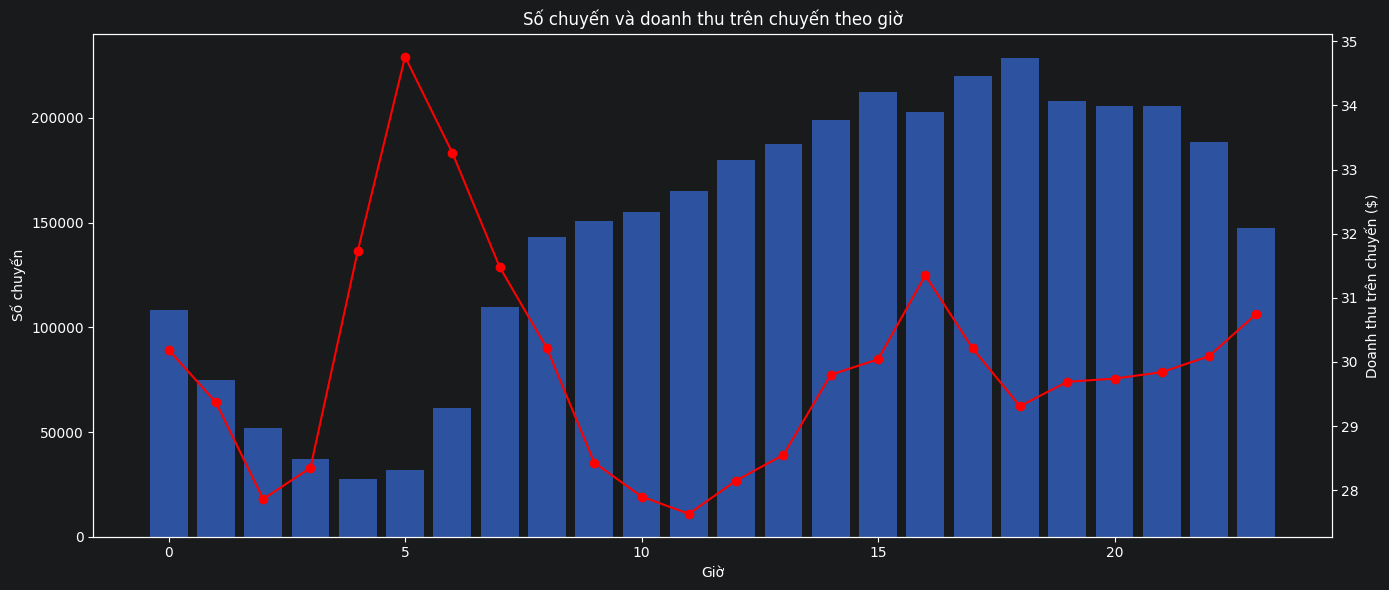

In [8]:
pdf = query2_df.toPandas()
pdf = pdf.sort_values("pickup_hour")
fig, ax1 = plt.subplots(figsize=(14,6))
# Cột: số chuyến
ax1.bar(
    pdf["pickup_hour"],
    pdf["Tong_so_chuyen"],
    alpha=0.7)

ax1.set_xlabel("Giờ")
ax1.set_ylabel("Số chuyến")

# Đường: doanh thu/chuyến
ax2 = ax1.twinx()

ax2.plot(
    pdf["pickup_hour"],
    pdf["Doanh_thu_tren_chuyen"],
    marker="o",
    color="red")

ax2.set_ylabel("Doanh thu trên chuyến ($)")

plt.title("Số chuyến và doanh thu trên chuyến theo giờ")

plt.tight_layout()
plt.show()

In [9]:
spark.stop()